In [1]:
""" Log
12/27/25 ---- Test for Ns =32, using the wce data up to t=0.5 and sce dat up to t=0.05 to construct the interpolation. Larger deviation for larger beta
12/30/25 ---- Corrected sce t to -t; 
--- The simple pole-excluding AAA cannot has trouble at low expansion order for G_k interpolation, but it seems fixable when doing Gij interpolation
----The Greedy AAA is more stable but yield inaccurate result when highly accurate wce/sce is available, just like the dimer test 
--- The 1D hubbard model, wce in t series has converegence radius much smaller for small system sizes and large beta, it is every non-convergent for some large beta. It gets better for larger system. 
"""

' Log\n12/27/25 ---- Test for Ns =32, using the wce data up to t=0.5 and sce dat up to t=0.05 to construct the interpolation. Larger deviation for larger beta\n12/30/25 ---- Corrected sce t to -t; \n--- The simple pole-excluding AAA cannot has trouble at low expansion order for G_k interpolation, but it seems fixable when doing Gij interpolation\n----The Greedy AAA is more stable but yield inaccurate result when highly accurate wce/sce is available, just like the dimer test \n--- The 1D hubbard model, wce in t series has converegence radius much smaller for small system sizes and large beta, it is every non-convergent for some large beta. It gets better for larger system. \n'

In [2]:
### Plotting the analytic solution G(t, U, iw_n) and G(t(U), U, iw_n)
import sys
sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt
import utilities as ut
import itertools as it
import pickle
from pydlr import dlr
import cvxpy as cp
import SCE as sce
import WCE as wce
from _bary_rational import AAA_adding0
import greedy_interpolation as greedy

In [3]:
beta = 40.0
Ntau = 401
Ns = 64
Nw = 400
Mat_fre = (2*np.linspace(0, Nw-1, Nw)+1)*np.pi/beta
wn = np.append(-np.flip(Mat_fre),Mat_fre)   # w_n = (2n+1)*pi/beta

In [4]:
t_values_wce = np.linspace(0.5,5,51)
t_values_sce = np.linspace(0,0.05,11)
Gij_iwn_sce = np.zeros((len(t_values_sce), wn.size, Ns, Ns), dtype ='complex')
Gij_iwn_wce = np.zeros((len(t_values_wce), wn.size, Ns, Ns), dtype ='complex')
# Gij_iwn_hf = np.zeros((len(t_values_wce), wn.size, Ns, Ns), dtype ='complex')
for t in range(t_values_sce.size):
    Gij_iwn_sce[t]= sce.Gij_sce_t(2, Ns, 1.0, wn, -t_values_sce[t])
for t in range(t_values_wce.size):
    print("t=",t)
    # Gij_iwn_hf[t], _ = wce.HF_G0(-t_values_wce[t], Ns, wn)
    Gij_iwn_wce[t]= wce.Gij_wce_U(2, Ns, 1.0, wn, beta, -t_values_wce[t])

t= 0
t= 1
t= 2
t= 3
t= 4
t= 5
t= 6
t= 7
t= 8
t= 9
t= 10
t= 11
t= 12
t= 13
t= 14
t= 15
t= 16
t= 17
t= 18
t= 19
t= 20
t= 21
t= 22
t= 23
t= 24
t= 25
t= 26
t= 27
t= 28
t= 29
t= 30
t= 31
t= 32
t= 33
t= 34
t= 35
t= 36
t= 37
t= 38
t= 39
t= 40
t= 41
t= 42
t= 43
t= 44
t= 45
t= 46
t= 47
t= 48
t= 49
t= 50


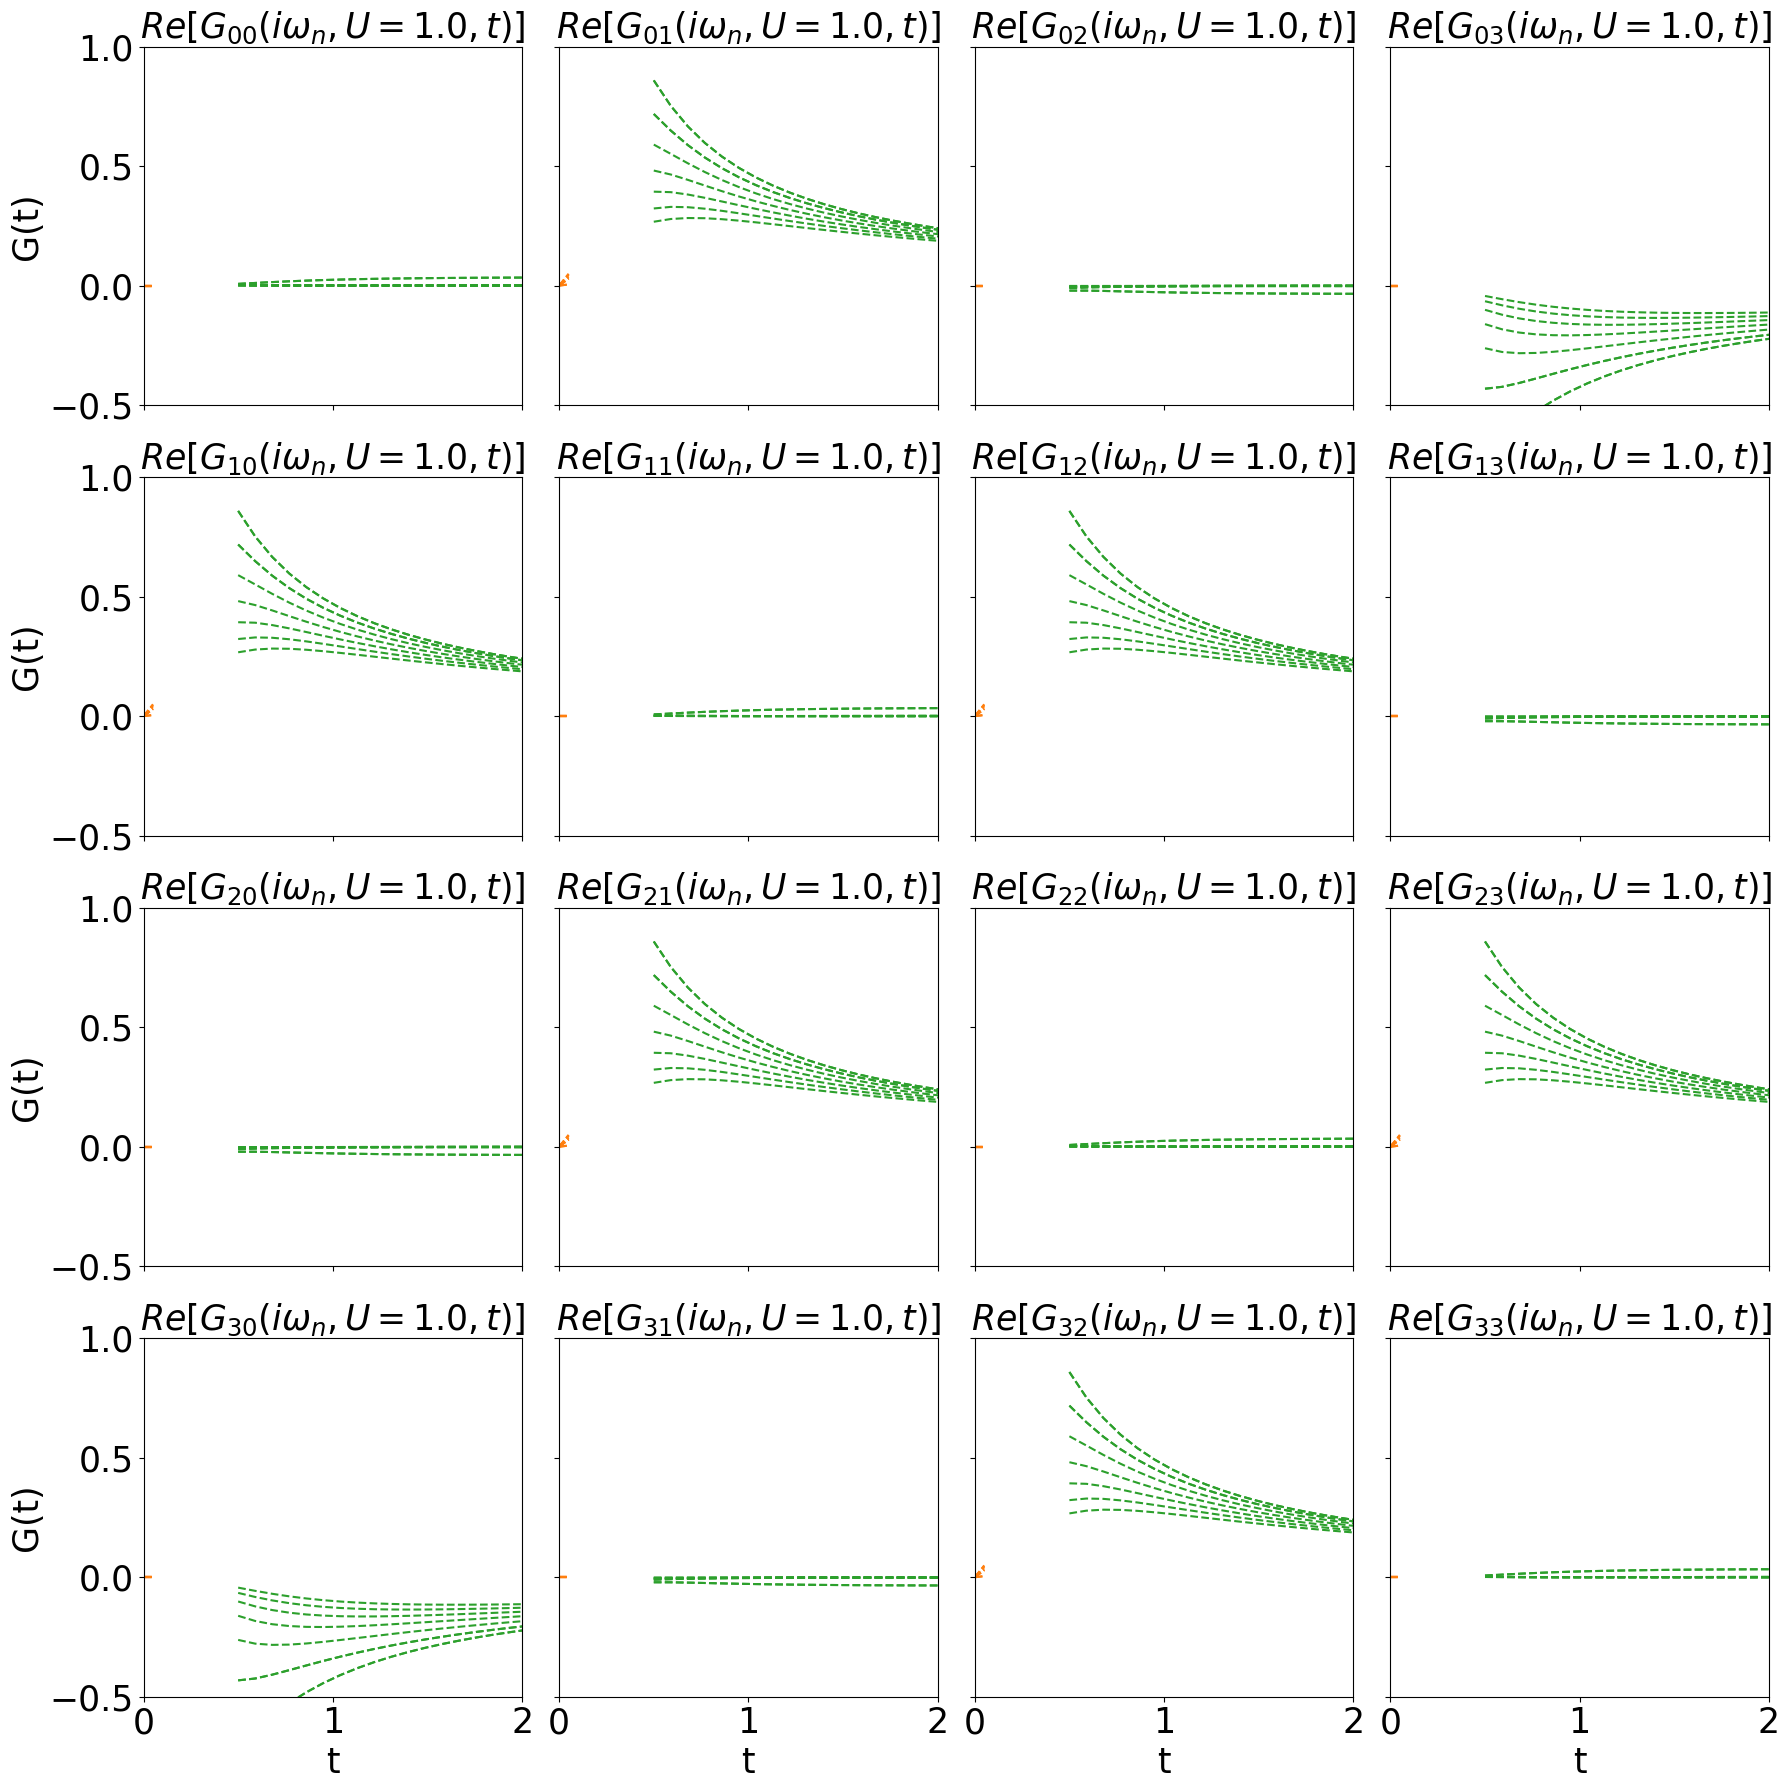

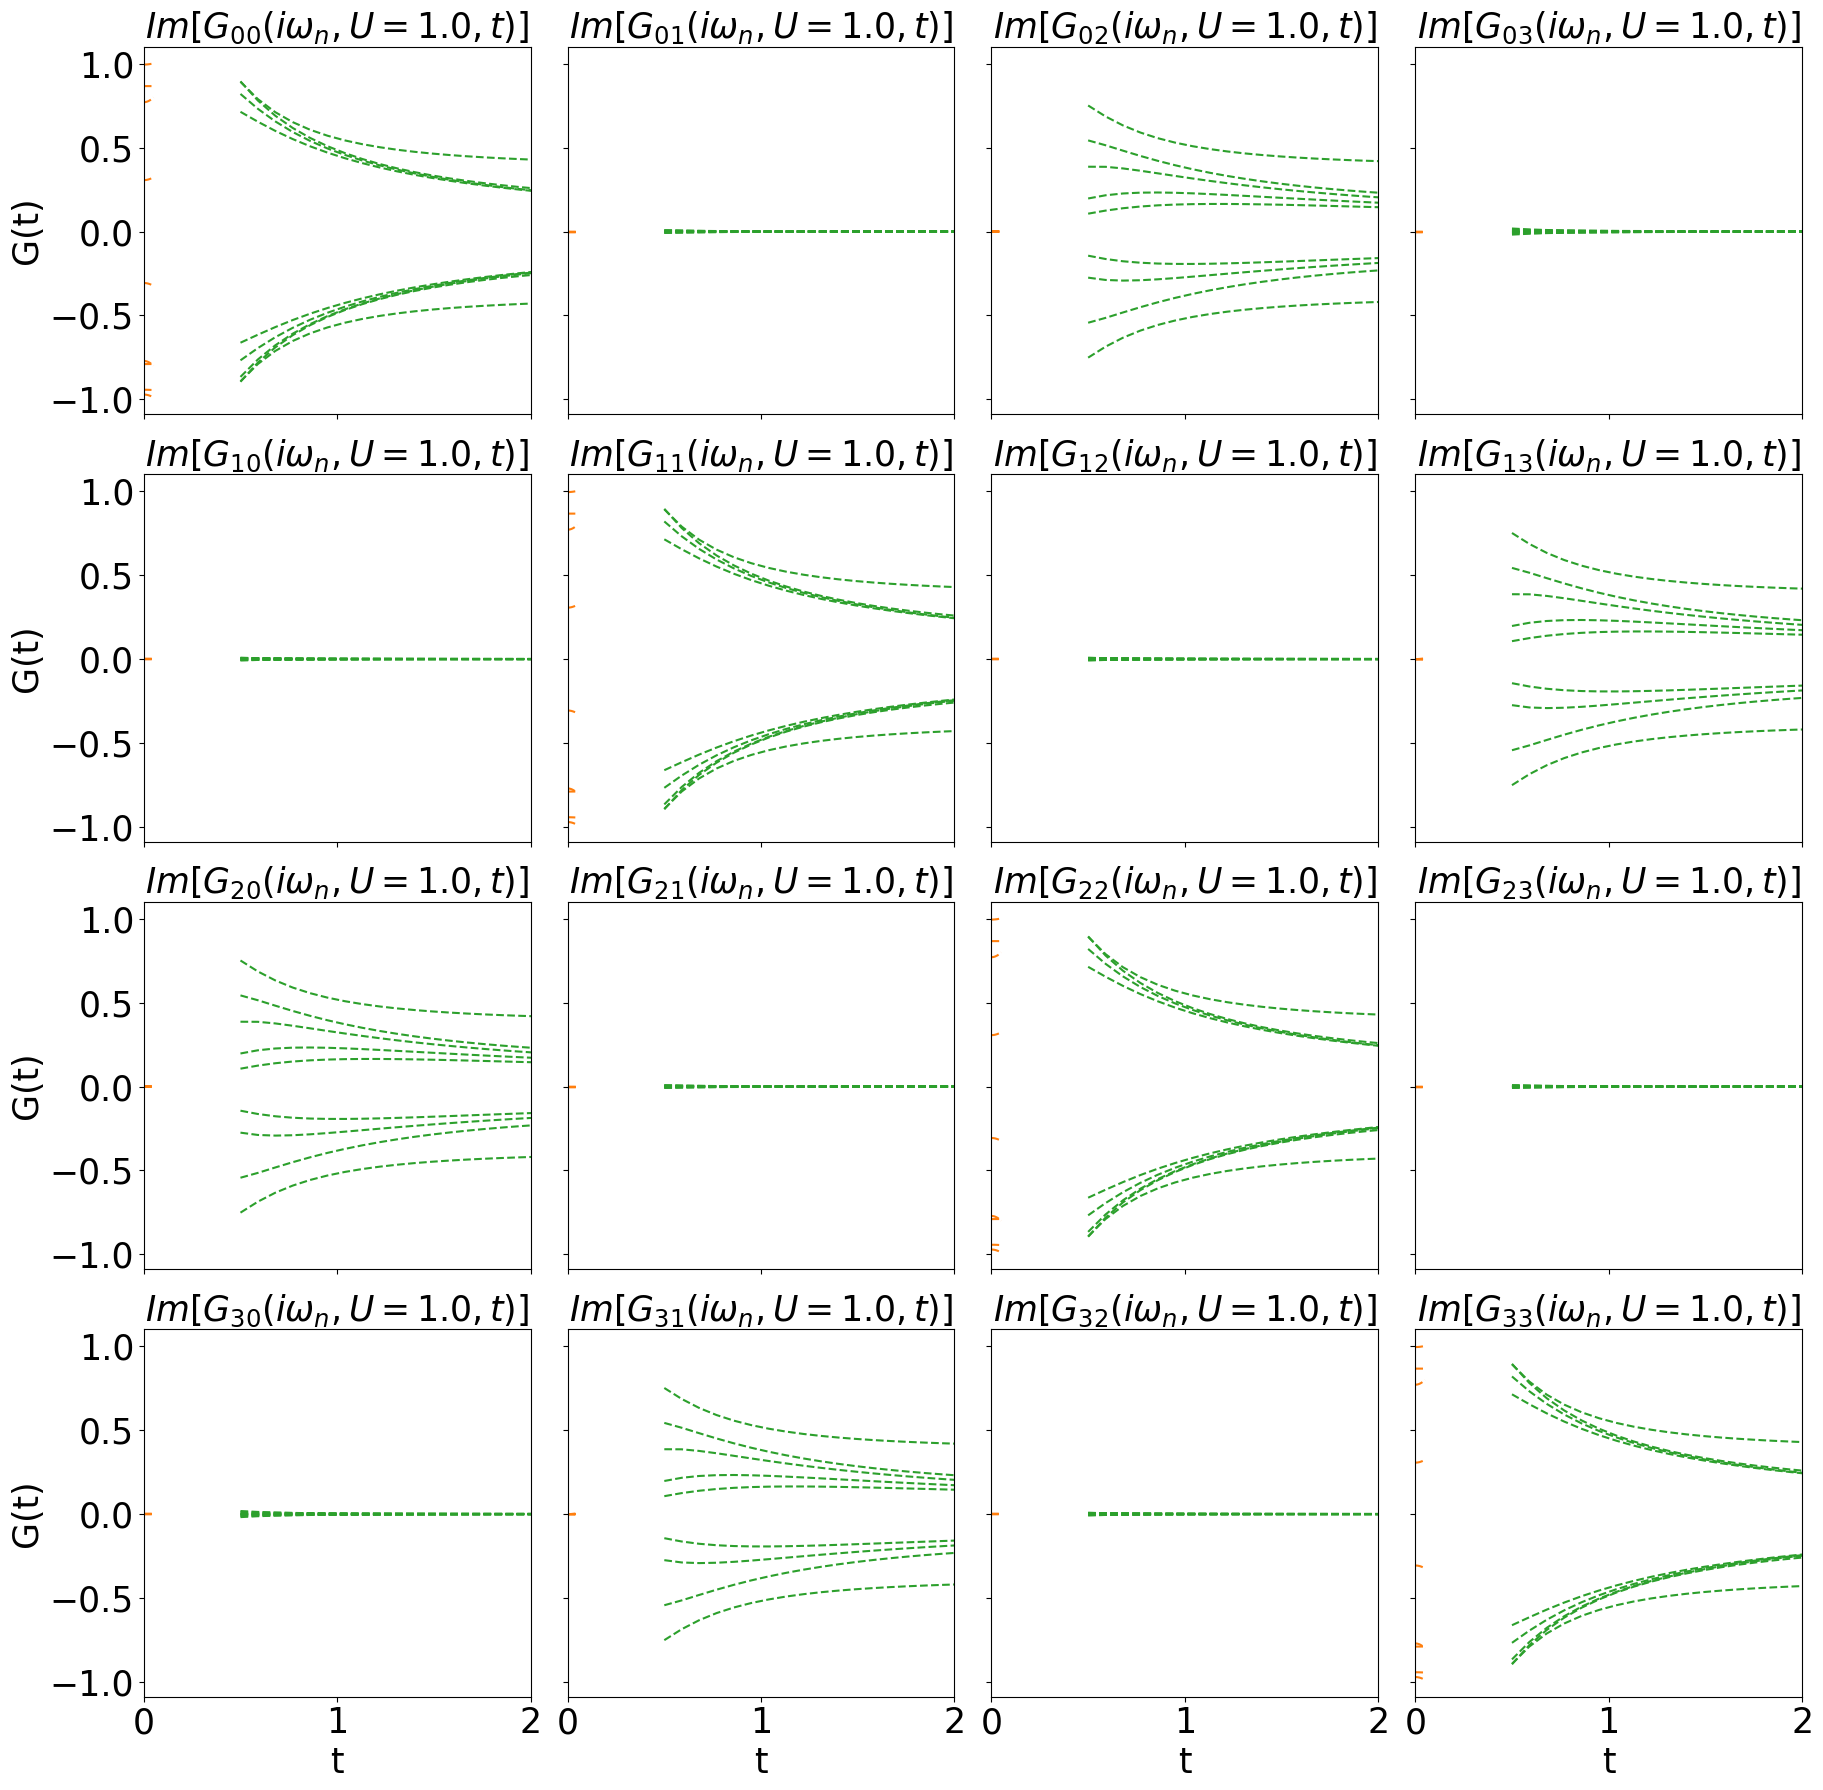

In [5]:
Ns_plot = 4

wn_id = [Nw+2, Nw+4, Nw+6, Nw+1, Nw, Nw-1, Nw-2, Nw-4, Nw-6]
fig, axes = plt.subplots(Ns_plot, Ns_plot, figsize=(18, 18),sharex=True, sharey=True)

for i in range(Ns_plot):
    for j in range(Ns_plot):
        ax = axes[i, j]
        for k in wn_id:
            # ax.plot(t_values_wce, Gij_iwn_hf[:, k, i ,j ].real, 'C0')
            ax.plot(t_values_sce, Gij_iwn_sce[:, k, i ,j ].real, 'C1--')
            ax.plot(t_values_wce, Gij_iwn_wce[:, k, i ,j ].real, 'C2--')
        ax.set_title(r'$Re[G_{%d%d}(i\omega_n,U=%.1f, t)]$'%(i,j,1.0), fontsize=25)
        ax.tick_params(labelsize=25)

        if i == Ns_plot - 1:
            ax.set_xlabel("t", fontsize=25)
            ax.set_xlim([0,2])
            ax.set_ylim([-0.5,1])
        if j == 0:
            ax.set_ylabel("G(t)", fontsize=25)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(Ns_plot, Ns_plot, figsize=(18, 18),sharex=True, sharey=True)

for i in range(Ns_plot):
    for j in range(Ns_plot):
        ax = axes[i, j]
        for k in wn_id:
            # ax.plot(t_values_wce, Gij_iwn_hf[:, k, i ,j ].imag, 'C0')
            ax.plot(t_values_sce, Gij_iwn_sce[:, k, i ,j ].imag, 'C1--')
            ax.plot(t_values_wce, Gij_iwn_wce[:, k, i ,j ].imag, 'C2--')
        ax.set_title(r'$Im[G_{%d%d}(i\omega_n,U=%.1f, t)]$'%(i,j,1.0), fontsize=25)
        ax.tick_params(labelsize=25)

        if i == Ns_plot - 1:
            ax.set_xlabel("t", fontsize=25)
            ax.set_xlim([0,2])
            # ax.set_ylim([-5,5])
        if j == 0:
            ax.set_ylabel("G(t)", fontsize=25)

plt.tight_layout()
plt.show()



In [6]:
### Constructing the interpolation data 
tl = 0.5
idl = np.argmin(np.abs(t_values_wce - tl))

wce_t = t_values_wce[idl:]
wce_G = Gij_iwn_wce[idl:, :, :, :]
print("WCE data length=", wce_G.shape)

tr = 0.05
idr = np.argmin(np.abs(t_values_sce - tr))

sce_t = t_values_sce[:idr ]
sce_G = Gij_iwn_sce[:idr, :, :, :]

t_app = np.concatenate([wce_t , sce_t ], axis=0)
G_app = np.concatenate([wce_G , sce_G ], axis=0)

print("SCE data length=", sce_G.shape)

WCE data length= (51, 800, 64, 64)
SCE data length= (10, 800, 64, 64)


In [7]:
### AAA interpolation 
err_bar1 = 1e-2
t_interp = np.linspace(0,5,501)

Nw_interp =  300
half = Nw_interp
mid = wn.size // 2 
print(wn.size, )
wn_ids = np.arange(mid-half, mid+half+1)

Ns_interp = 4
Gij_iwn_interp_greedy = np.zeros((t_interp.size, wn.size, Ns_interp, Ns_interp), dtype = complex)


# for n in range(wn.size):
for n in wn_ids:
    print("n=", n, "w_n=", wn[n])
    for i in range(Ns_interp):
        for j in range(Ns_interp):
            if (-1)**(i+j) >0:
                # Gij_iwn_interp_greedy[:, n, i, j] = greedy.G_interp(sce_G[:, n, i, j].imag, sce_t, wce_G[:, n, i, j].imag, wce_t, t_interp,  err=err_bar1, max_terms= 40)
                # Gij_iwn_interp_greedy[:, n, i, j] = 1j*Gij_iwn_interp_greedy[:, n, i, j]
                r = AAA_adding0(t_app, G_app[:, n, i, j].imag,  rtol=err_bar1, max_terms= 20)
                Gij_iwn_interp_greedy[:, n, i, j] = 1j*r(t_interp)
            else:
                # Gij_iwn_interp_greedy[:, n, i, j] = greedy.G_interp(sce_G[:, n, i, j].real, sce_t, wce_G[:, n, i, j].real, wce_t, t_interp,  err=err_bar1, max_terms= 40)
                r = AAA_adding0(t_app, G_app[:, n, i, j].real,  rtol=err_bar1, max_terms= 20)
                Gij_iwn_interp_greedy[:, n, i, j] = r(t_interp)

800
n= 100 w_n= -47.04534998750715
n= 101 w_n= -46.88827035482766
n= 102 w_n= -46.73119072214817
n= 103 w_n= -46.57411108946868
n= 104 w_n= -46.41703145678919
n= 105 w_n= -46.259951824109706
n= 106 w_n= -46.102872191430215
n= 107 w_n= -45.945792558750725
n= 108 w_n= -45.788712926071234
n= 109 w_n= -45.631633293391744
n= 110 w_n= -45.47455366071226
n= 111 w_n= -45.31747402803277
n= 112 w_n= -45.16039439535327
n= 113 w_n= -45.00331476267378
n= 114 w_n= -44.8462351299943
n= 115 w_n= -44.68915549731481
n= 116 w_n= -44.53207586463532
n= 117 w_n= -44.374996231955826
n= 118 w_n= -44.217916599276336
n= 119 w_n= -44.06083696659685
n= 120 w_n= -43.90375733391736
n= 121 w_n= -43.74667770123787
n= 122 w_n= -43.58959806855838
n= 123 w_n= -43.43251843587889
n= 124 w_n= -43.2754388031994
n= 125 w_n= -43.11835917051991
n= 126 w_n= -42.96127953784042
n= 127 w_n= -42.80419990516093
n= 128 w_n= -42.647120272481445
n= 129 w_n= -42.490040639801954
n= 130 w_n= -42.332961007122464
n= 131 w_n= -42.17588137444

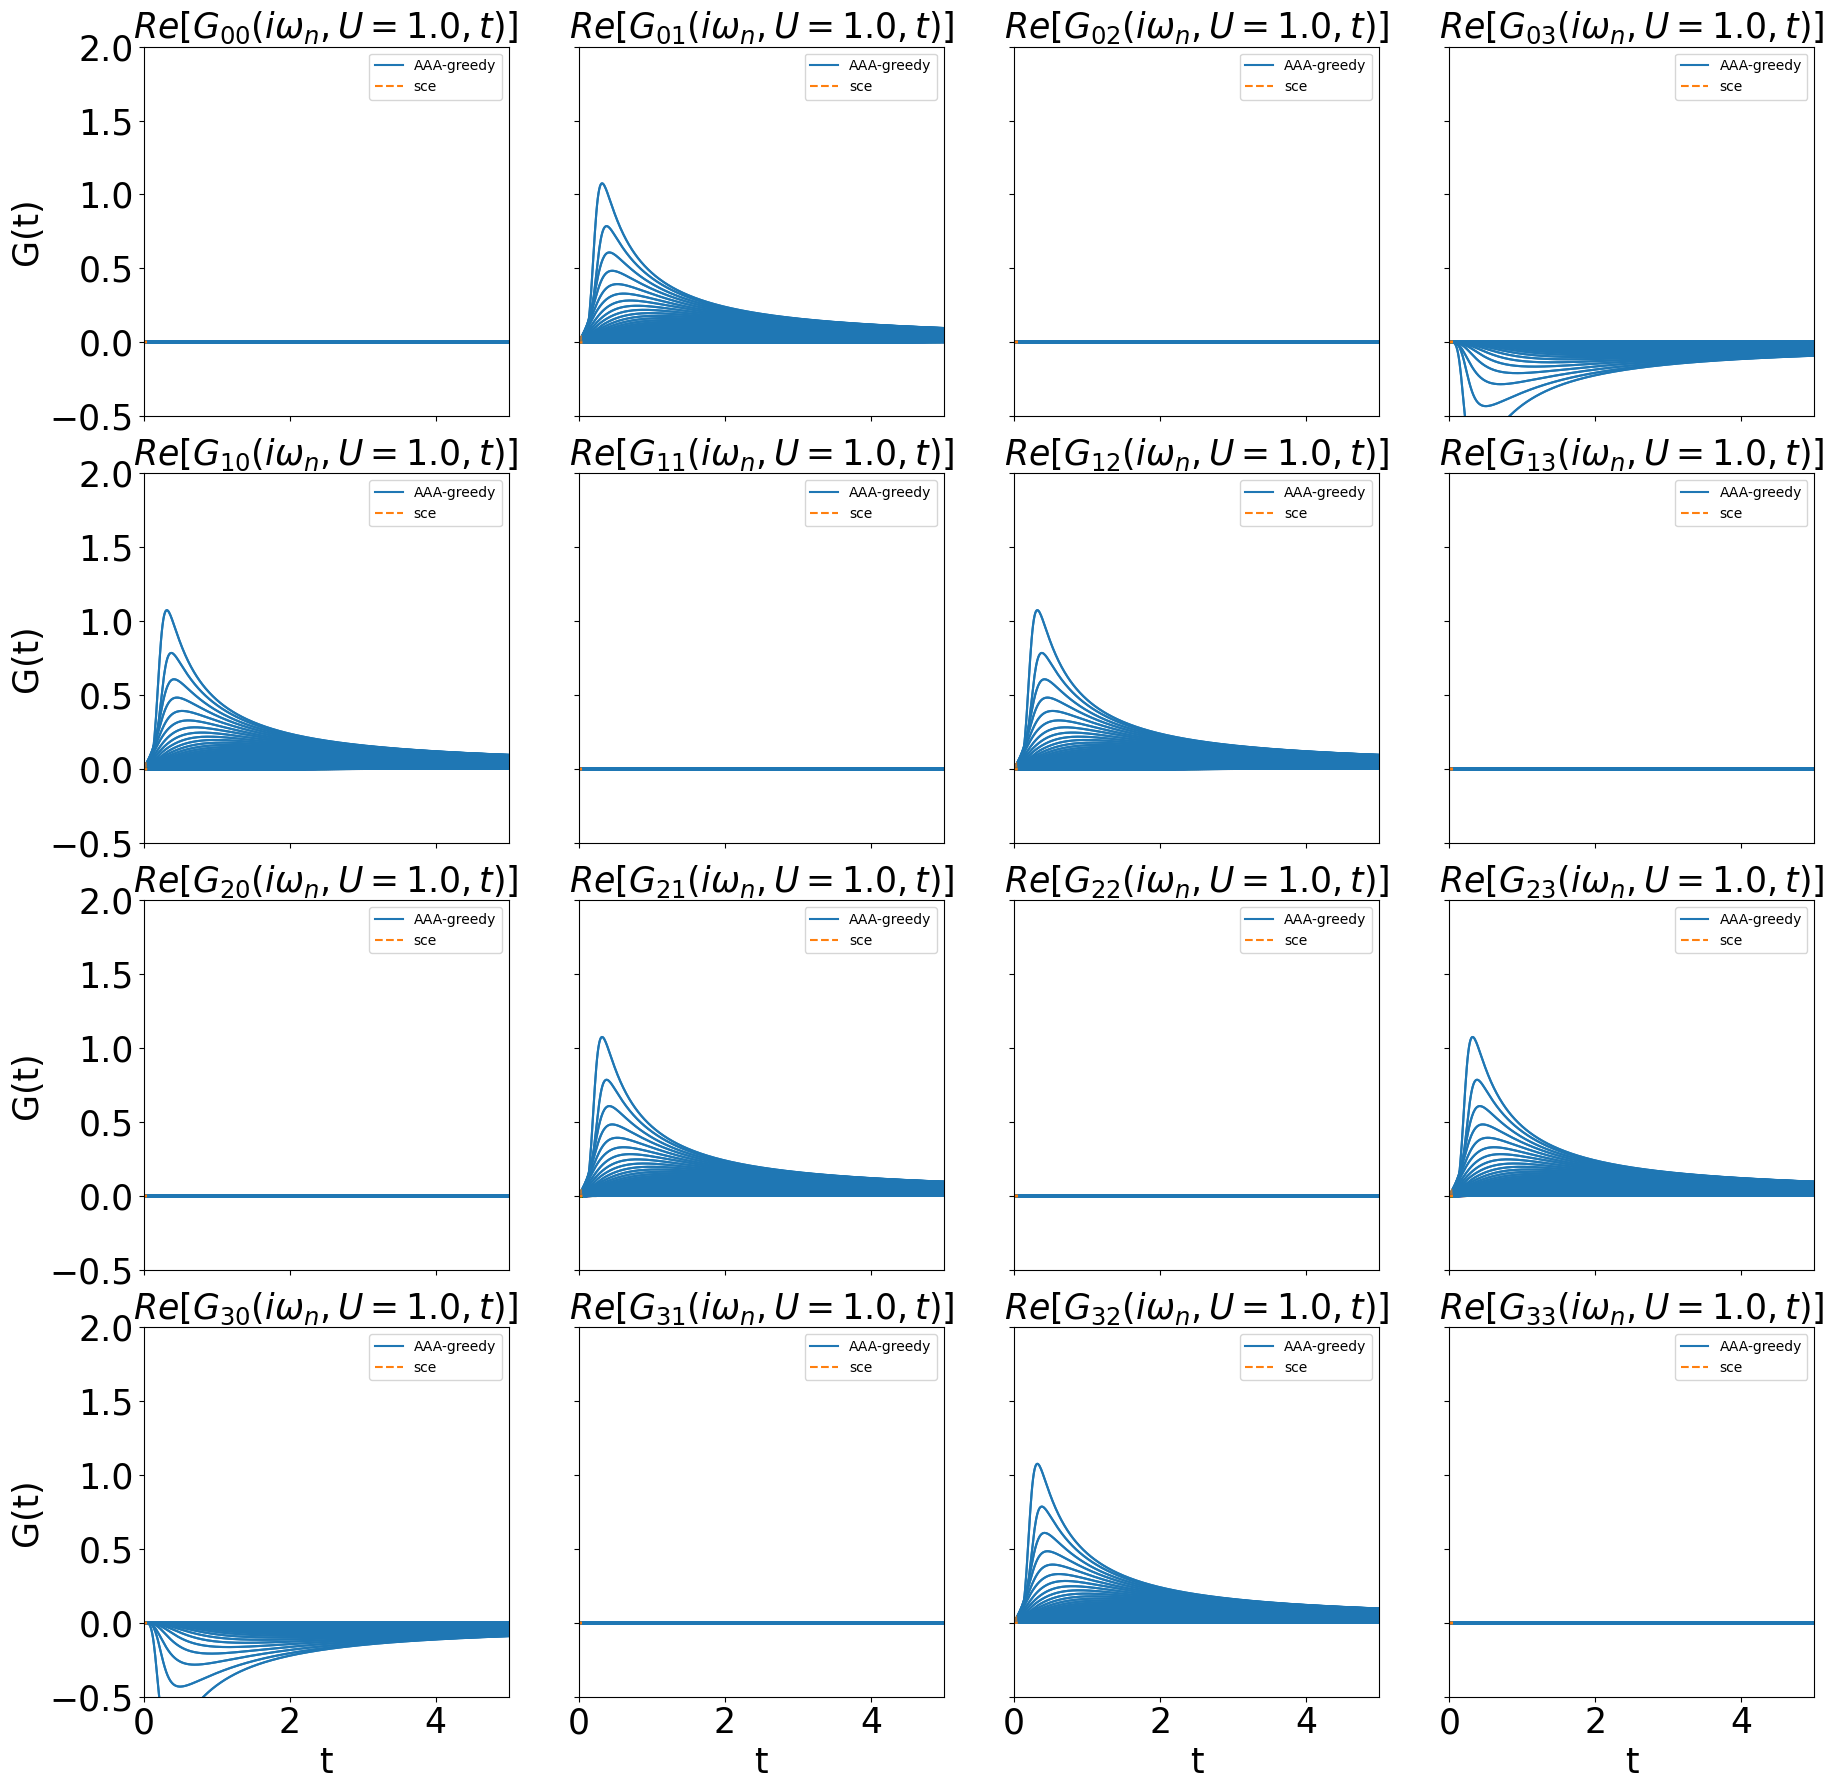

In [8]:
Ns_plot = 4
fig, axes = plt.subplots(Ns_plot, Ns_plot, figsize=(18, 18),sharex=True, sharey=True)

for i in range(Ns_plot):
    for j in range(Ns_plot):
        ax = axes[i, j]
        for k in wn_ids:
            ax.plot(t_interp, Gij_iwn_interp_greedy[:, k, i ,j ].real, 'C0')
            ax.plot(t_values_sce, Gij_iwn_sce[:, k, i ,j ].real, 'C1--')
            # ax.plot(t_values_wce, Gij_iwn_wce[:, k, i ,j ].real, 'C2--')
            # ax.plot(t_values_wce, Gij_iwn_hf[:, k, i ,j ].real, 'C3--')

        ax.plot(t_interp, Gij_iwn_interp_greedy[:, k, i ,j ].real, 'C0', label= 'AAA-greedy')
        ax.plot(t_values_sce, Gij_iwn_sce[:, k, i ,j ].real, 'C1--', label= 'sce')
        # ax.plot(t_values_wce, Gij_iwn_wce[:, k, i ,j ].real, 'C2--', label= 'wce')
        # ax.plot(t_values_wce, Gij_iwn_hf[:, k, i ,j ].real, 'C3--', label= 'HF')
        ax.set_title(r'$Re[G_{%d%d}(i\omega_n,U=%.1f, t)]$'%(i,j,1.0), fontsize=25)
        ax.tick_params(labelsize=25)
        ax.legend()
        if i == Ns_plot - 1:
            ax.set_xlabel("t", fontsize=25)
            ax.set_xlim([0,5])
            ax.set_ylim([-0.5,2])
        if j == 0:
            ax.set_ylabel("G(t)", fontsize=25)

plt.tight_layout()
plt.show()

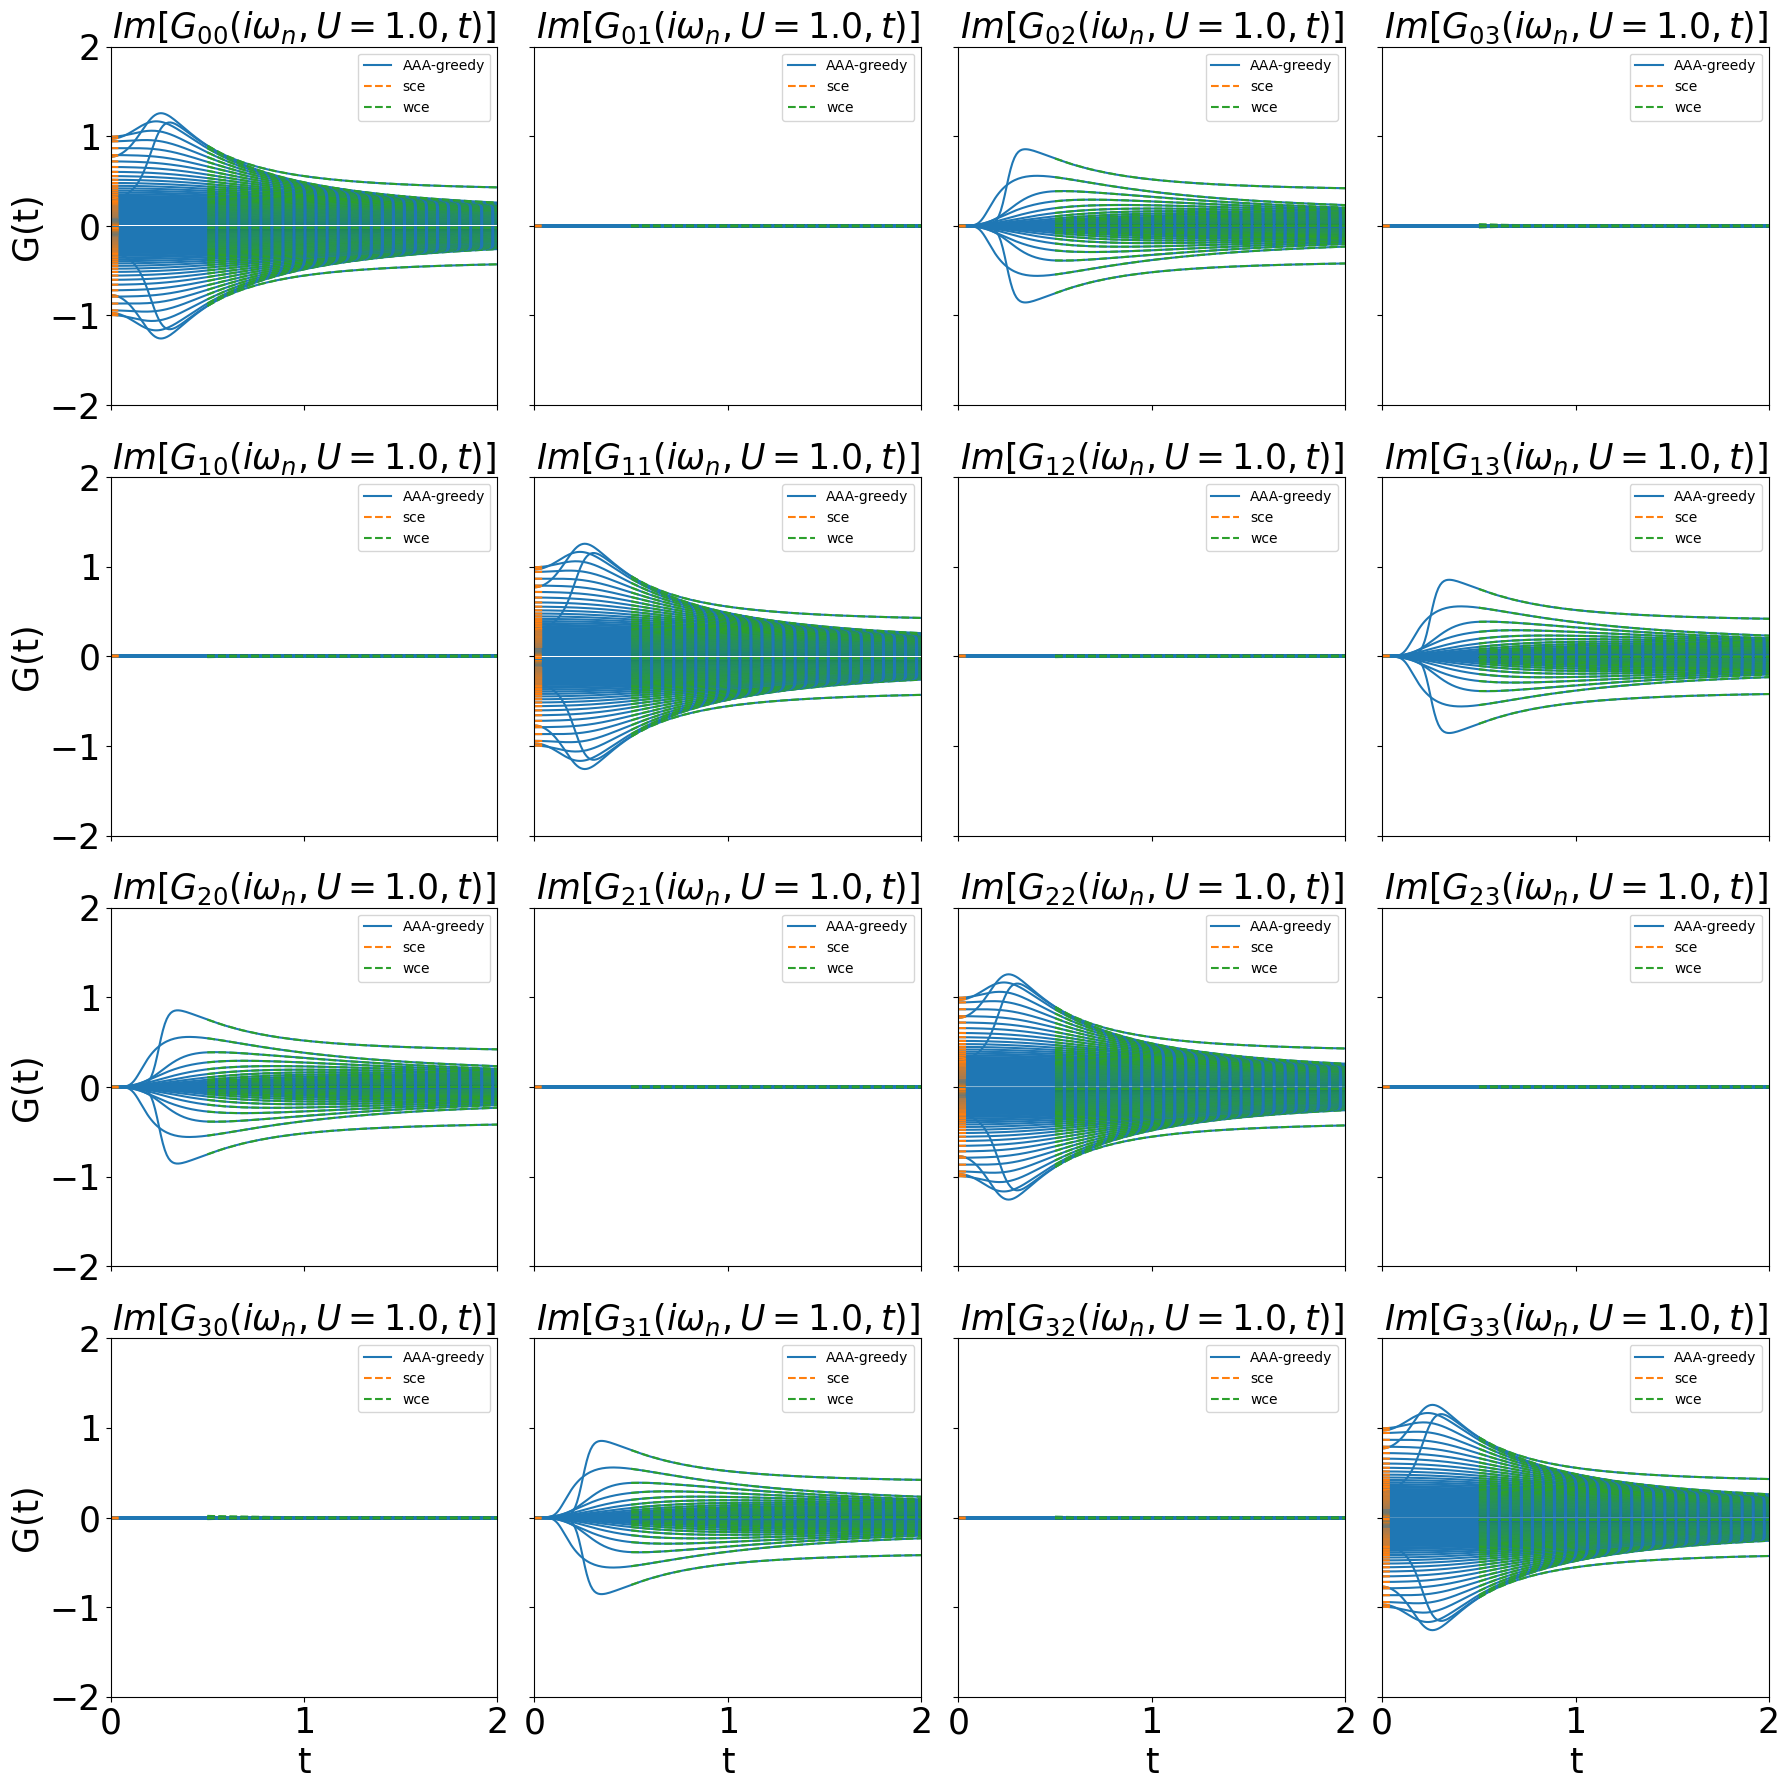

In [9]:
fig, axes = plt.subplots(Ns_plot, Ns_plot, figsize=(18, 18),sharex=True, sharey=True)
wn_id = [Nw+5, Nw+4, Nw+3, Nw+2, Nw+1, Nw, Nw-1, Nw-2, Nw-3, Nw-4]
for i in range(Ns_plot):
    for j in range(Ns_plot):
        ax = axes[i, j]
        for k in wn_ids:
        # for k in range(wn.size):
            ax.plot(t_interp, Gij_iwn_interp_greedy[:, k, i ,j ].imag, 'C0')
            ax.plot(t_values_sce, Gij_iwn_sce[:, k, i ,j ].imag, 'C1--')
            ax.plot(t_values_wce, Gij_iwn_wce[:, k, i ,j ].imag, 'C2--')
            # ax.plot(t_values_wce, Gij_iwn_hf[:, k, i ,j ].imag, 'C3--')
            
        ax.plot(t_interp, Gij_iwn_interp_greedy[:, k, i ,j ].imag, 'C0', label= 'AAA-greedy')
        ax.plot(t_values_sce, Gij_iwn_sce[:, k, i ,j ].imag, 'C1--', label= 'sce')
        ax.plot(t_values_wce, Gij_iwn_wce[:, k, i ,j ].imag, 'C2--', label= 'wce')
        # ax.plot(t_values_wce, Gij_iwn_hf[:, k, i ,j ].imag, 'C3--', label= 'HF')
        ax.set_title(r'$Im[G_{%d%d}(i\omega_n,U=%.1f, t)]$'%(i,j,1.0), fontsize=25)
        ax.tick_params(labelsize=25)
        ax.legend()
        if i == Ns_plot - 1:
            ax.set_xlabel("t", fontsize=25)
            ax.set_xlim([0,2])
            ax.set_ylim([-2,2])
        if j == 0:
            ax.set_ylabel("G(t)", fontsize=25)

plt.tight_layout()
plt.show()

0.5
601 4817616


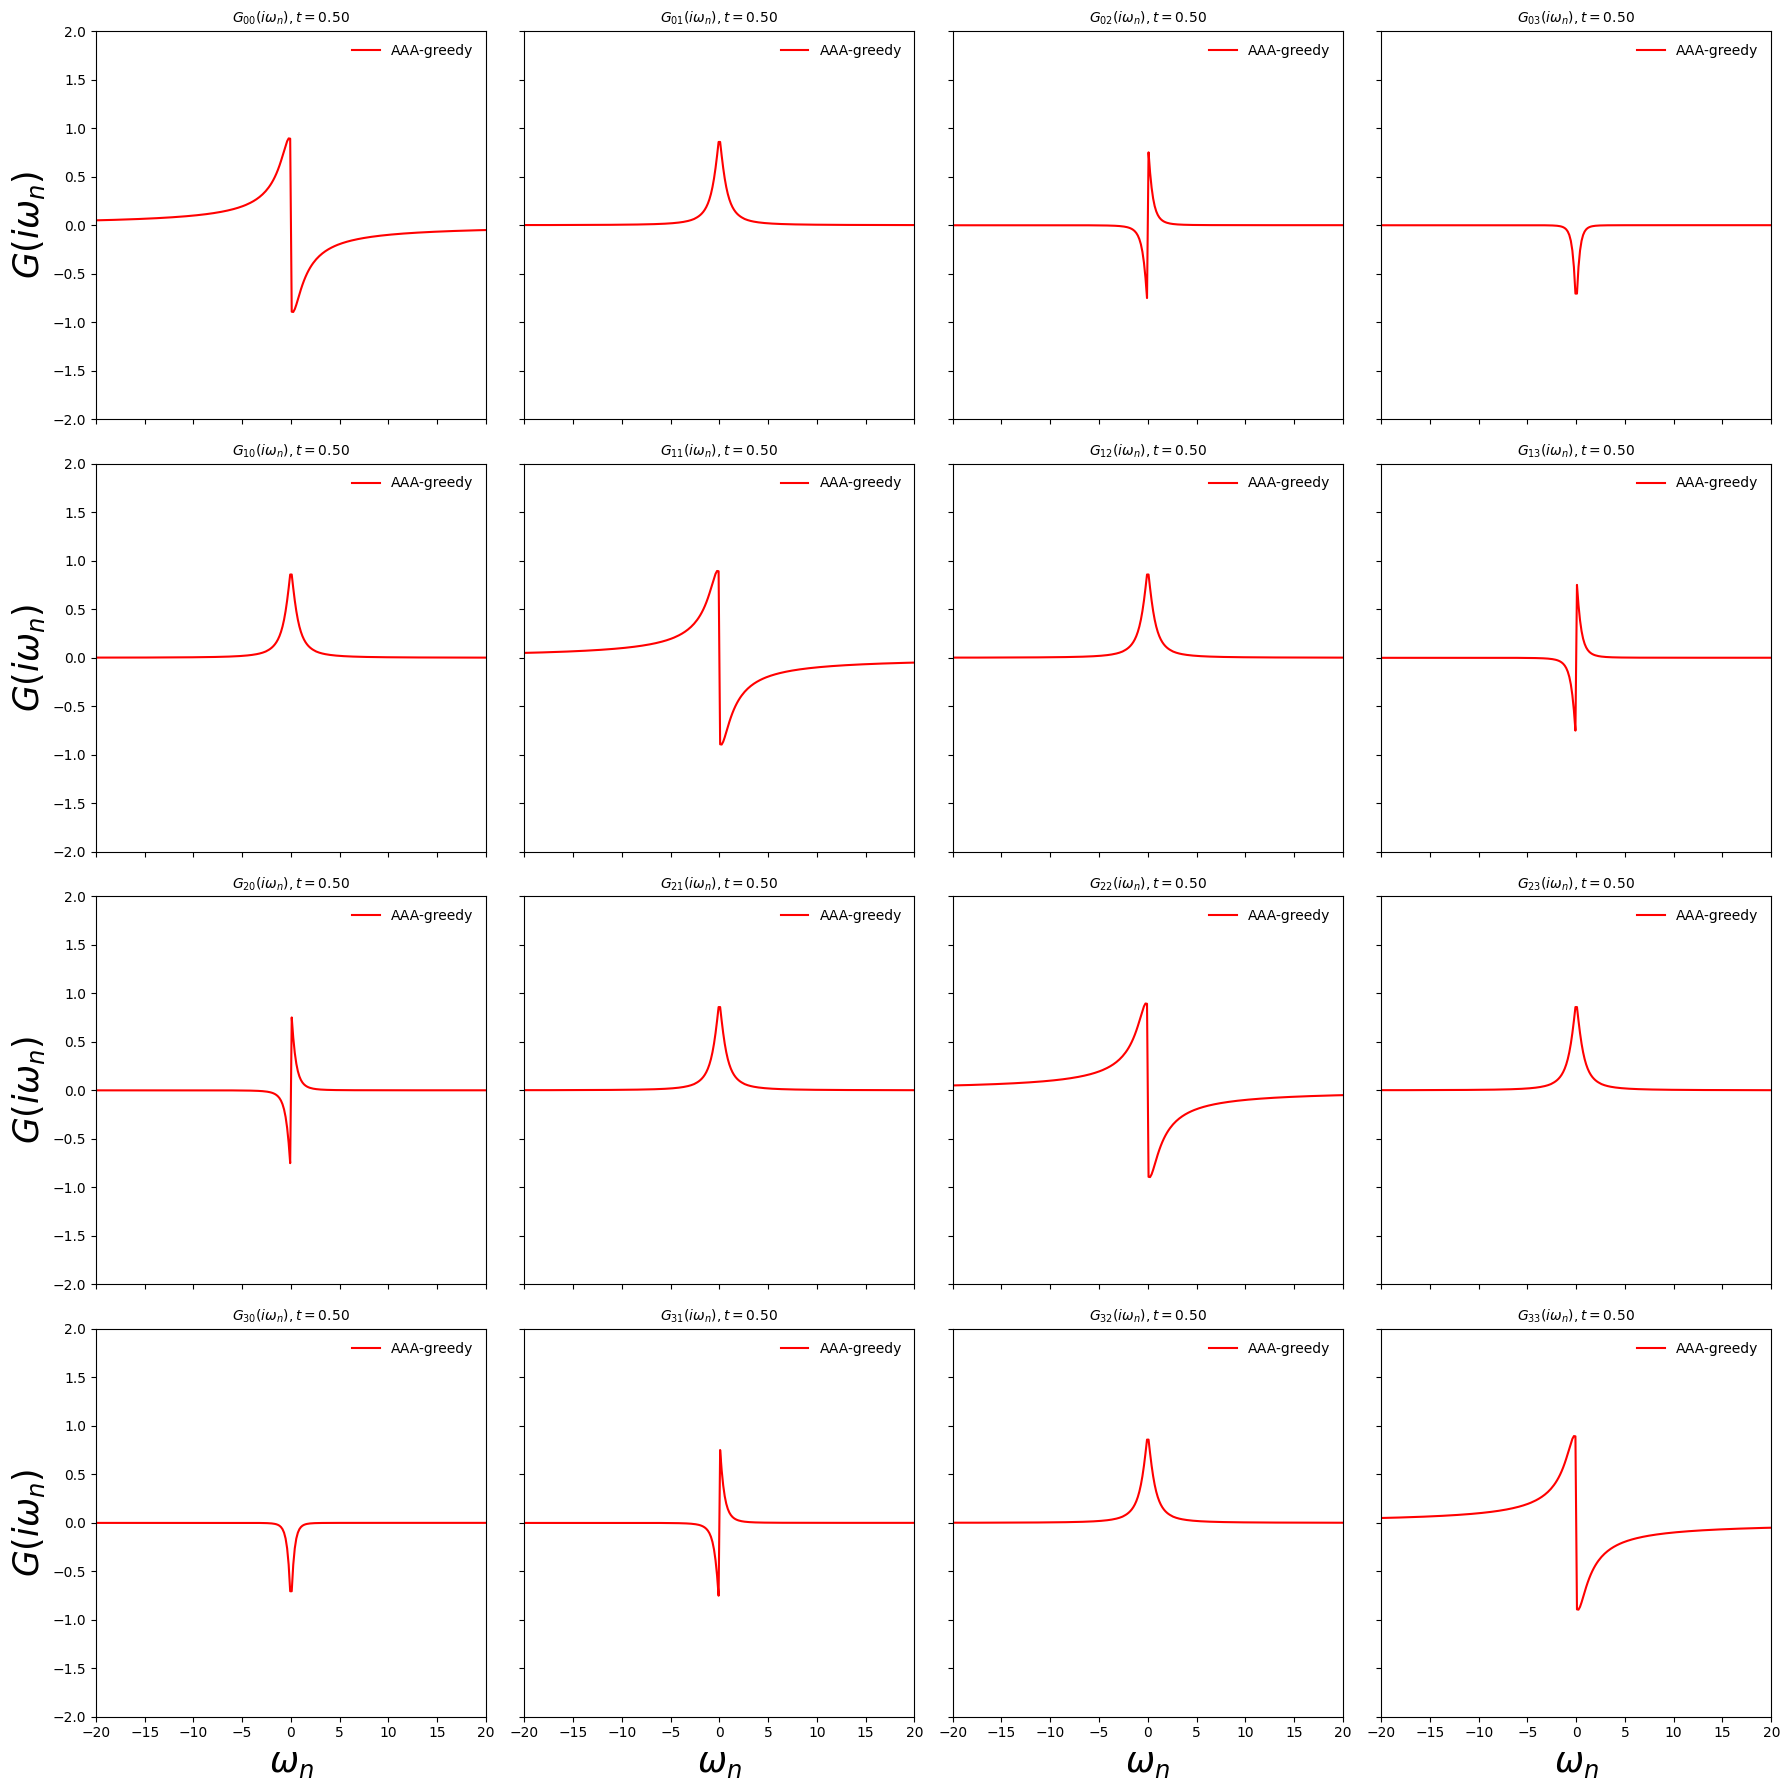

In [10]:
t_test = 0.5
id_aaa = np.argmin(np.abs(t_test - t_interp))
print(t_interp[id_aaa])


mask = (np.arange(wn.size)  >= mid - half) & (np.arange(wn.size) <= mid + half)
wn_interp = wn[mask]
Gij_iwn_interp = Gij_iwn_interp_greedy[:, mask, :,:]

print(wn_interp.size, Gij_iwn_interp.size)
Ns_plot = 4
fig, axes = plt.subplots(Ns_plot, Ns_plot, figsize=(18, 18),sharex=True, sharey=True)

for i in range(Ns_plot):
    for j in range(Ns_plot):
        ax = axes[i, j]
        if (-1)**(i+j) <0:
            ax.plot(wn_interp, Gij_iwn_interp[id_aaa, :, i ,j ].real, 'r', label= 'AAA-greedy')
        else:
            ax.plot(wn_interp, Gij_iwn_interp[id_aaa, :, i ,j ].imag, 'r', label= 'AAA-greedy')
        ax.set_title(r'$G_{%d%d}(i\omega_n), t=%.2f$'%(i,j, t_interp[id_aaa]), fontsize=10)
        ax.tick_params(labelsize=10)
        ax.legend(frameon = False)
        if i == Ns_plot - 1:
            ax.set_xlabel(r"$\omega_n$", fontsize=25)
            ax.set_xlim([-20,20])
            ax.set_ylim([-2,2])
        if j == 0:
            ax.set_ylabel(r"$G(i\omega_n)$", fontsize=25)

plt.tight_layout()
plt.show()


In [ ]:
# tau = np.linspace(0,beta, 401)
# Gii_tau_interp = wce.Gij_iwn_to_Gij_tau(Gij_iwn_interp[id_aaa,:,0,0].reshape(wn_interp.size,1,1), wn_interp, tau, beta)

# Ns_values_QMC =  [16, 32, 64, 128]
# U_values_QMC  = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
# whole_Gii_tau_QMC = np.load('/pscratch/sd/y/yzhu4/2point_Pade/1D_hubbard/data_AFQMC/Gii_AFQMC.npy')

# Ns_id = Ns_values_QMC.index(64)
# Gii_tau_QMC = whole_Gii_tau_QMC[Ns_id]

# U_id = np.argmin(np.abs(U_values_QMC - 1/t_interp[id_aaa]))
    
# plt.plot(tau, -Gii_tau_interp[:,0,0], label = 'AAA')
# plt.plot(tau, Gii_tau_QMC[U_id, :], '--', label = 'QMC')
# plt.title("Ns=%d, t=%.2f"%(Ns,t_interp[id_aaa]))
# plt.ylabel(r"$G_{00}(\tau)$")
# plt.xlabel(r"$\tau$")
# plt.legend()

FileNotFoundError: [Errno 2] No such file or directory: '/pscratch/sd/y/yzhu4/2point_Pade/1D_hubbard/data_AFQMC/Gii_AFQMC.npy'

In [ ]:
##### Plotting function when get all Gij

# Ns_plot = 4
# fig, axes = plt.subplots(Ns_plot, Ns_plot, figsize=(18, 18),sharex=True, sharey=True)
# for i in range(Ns_plot):
#     for j in range(Ns_plot):
#         ax = axes[i, j]
#         ax.plot(tau, -Gij_tau_interp[:, i ,j ].real, 'k', label= 'AAA-recon')
#         ax.set_title(r'$-G_{%d%d}(\tau), t=%.2f$'%(i,j, t_interp[id_aaa]), fontsize=10)
#         ax.tick_params(labelsize=10)
#         ax.legend()
#         if i == Ns_plot - 1:
#             ax.set_xlabel(r"$\tau$", fontsize=25)
#             ax.set_xlim([0, beta])
#             ax.set_ylim([-2,2])
#         if j == 0:
#             ax.set_ylabel(r"$G(\tau)$", fontsize=25)

# plt.tight_layout()
# plt.show()

In [ ]:
# i = 0
# j = 0
# n = Nw

# # Nt_end = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# plt.figure(0)
# plt.plot(t_values_wce, Gij_iwn_interp[:,n, i,j].imag, 'C0', label = 'original-AAA')
# plt.plot(t_values_wce, Gij_iwn_hf[:,n, i,j].imag, 'C2', label = 'HF')
# for Nt in range(25):
#     print("sce t_end is", sce_t[Nt-1])
#     t_app = np.concatenate([sce_t[: Nt] , wce_t ], axis=0)
#     G_app = np.concatenate([sce_G[: Nt] , wce_G ], axis=0)
#     r_AAA = AAA_adding0(t_app, 1j*G_app[:, n, i, j].imag,  rtol=err_bar1, max_terms= 40)
#     G_AAA = r_AAA(t_values_wce)
#     plt.plot(t_values_wce, G_AAA.imag, 'C1--')
    
# plt.plot(t_values_wce, G_AAA.imag, 'k--', linewidth =2, label = 'AAA')
# plt.xlim([0,2])
# plt.ylim([-2,2])
# plt.legend()

# i = 0
# j = 1
# plt.figure(1)
# plt.plot(t_values_wce, Gij_iwn_interp[:,n, i,j].real, 'C0', label = 'original-AAA')
# plt.plot(t_values_wce, Gij_iwn_hf[:,n, i,j].real, 'C2', label = 'HF')
# for Nt in range(25):
#     print("sce t_end is", sce_t[Nt-1])
#     t_app = np.concatenate([sce_t[: Nt] , wce_t ], axis=0)
#     G_app = np.concatenate([sce_G[: Nt] , wce_G ], axis=0)
#     r_AAA = AAA_adding0(t_app, G_app[:, n, i, j].real,  rtol=err_bar1, max_terms= 40)
#     G_AAA = r_AAA(t_values_wce)
#     plt.plot(t_values_wce, G_AAA.real, 'C1--')
    
# plt.plot(t_values_wce, G_AAA.real, 'k--', linewidth =2, label = 'AAA')
# plt.xlim([0,2])
# plt.ylim([-2,2])
# plt.legend()

# # print(sce_t.size)
# # print(wce_t.size)

